In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from jax import random
import seaborn as snb

import bayesian

# use 64-bit precision
from jax import config
config.update("jax_enable_x64", True)

# style stuff
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.25)
colors = snb.color_palette()

# 02477 Bayesian Machine Learning Exam Template

# Part 1
Solution to Q1.1 through Q1.5: See handwritten solution on appendix A

(5, 4)
[ 0.95336134  0.26645658 -0.69327731  0.12892157]
[[ 0.03658534 -0.04402131  0.0148169  -0.0014999 ]
 [-0.04402131  0.13294307 -0.06430176  0.00799773]
 [ 0.0148169  -0.06430176  0.03584205 -0.00480552]
 [-0.0014999   0.00799773 -0.00480552  0.00066975]]
[ 0.9470195   0.2469239  -0.67903942  0.12686206]
ystar -0.9982878551999651
0.07396222755797971


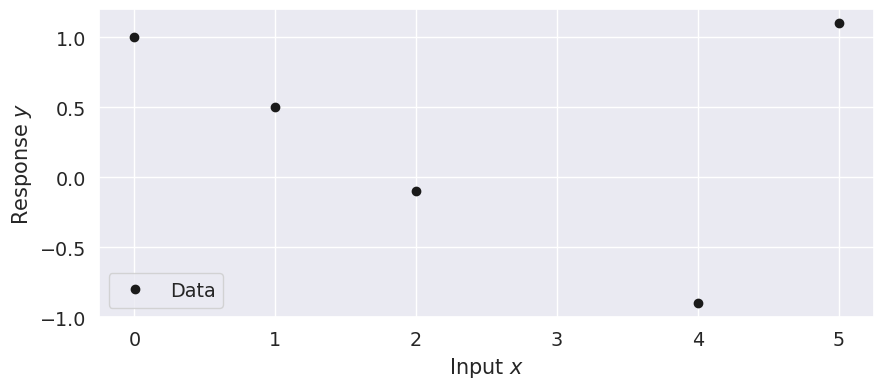

In [3]:
# Part 1
x = jnp.array([0, 1, 2, 4, 5])
y = jnp.array([1.0, 0.5, -0.1, -0.9, 1.1])

Phi = jnp.array([x**n for n in range(4)]).T
print(Phi.shape)

w_ml = jnp.linalg.solve(Phi.T @ Phi, Phi.T @ y)
print(w_ml)

sigma = 1/5

S_wy = jnp.linalg.inv(1/2 * jnp.eye(4) + Phi.T @ Phi /sigma**2)
mu_wy = S_wy @ Phi.T @ y /sigma**2
print(S_wy)
print(mu_wy)
x_star = 3
Phi_star = jnp.array([x_star**n for n in range(4)]).T
print("ystar", Phi_star @ mu_wy)
print(sigma**2 + Phi_star.T @ S_wy @ Phi_star)

bayesian.plot_data(x, y)



# Part 2
Solution to Q2.1 through Q2.5: See handwritten solution on appendix B

In [18]:
# Part 2
# 2.1

# We compute the approximate posterior mean of w1 by marginalizing over w2 to find the approximate posterior distribution of w1 and then
# calculating the first moment of q(w1). We calculate the variance by calculating the second moment and using the computational variance formula.

w_grid = jnp.array([0.09, 0.12, 0, 0.12, 0.2, 0.12, 0, 0.12, 0.23]).reshape(3,3)
print(w_grid)
w1_p = w_grid.sum(-1)
print(w1_p)
print("sum = ", w1_p.sum())
w1 = jnp.linspace(0.5, 0.7, 3)
w2 = jnp.linspace(0.1, 0.3, 3)[::-1]
print(w1)
mean = (w1_p * w1).sum()
var = (w1_p * (w1**2)).sum() - mean**2

print(f"{mean=}, {var=}")
print("alternative var", sum([(w1[i] - mean)**2 * w1_p[i] for i in range(3)]))
print((w1_p * (w1-mean)**2).sum())

# 2.2
log_npdf = lambda x, m, v: -(x-m)**2/(2*v) - 0.5*jnp.log(2*jnp.pi*v)
npdf = lambda x, m, v: jnp.exp(log_npdf(x, m, v))
# we take the expectation of the likelyhood over the approximate posterior
ystar = 4
xstar = 4
p_ystar = 0
f = lambda w1, w2, x : jnp.exp(w1 + w2*x)
sigma2 = 0.5
for i, w_1 in enumerate(w1):
    for j, w_2  in enumerate(w2):
        p_ystar += npdf(ystar, f(w_1, w_2, xstar), sigma2) * w_grid[i, j] 

print(f"{p_ystar=}")

# Redo this exercise later


# Solution

# list all pairs (w1, w2) of non-zero prob w1 w2 p
weights_and_probs = np.array([ 
(0.5, 0.2, 0.12),
(0.5, 0.3, 0.09),
(0.6, 0.1, 0.12),
(0.6, 0.2, 0.20),
(0.6, 0.3, 0.12),
(0.7, 0.1, 0.23),
(0.7, 0.2, 0.12)])
assert sum([p for (w1, w1, p) in weights_and_probs]) == 1
mean_w1 = sum([w1 * p for (w1, w2, p) in weights_and_probs])
var_w1 = sum([(w1- mean_w1)**2 * p for (w1, w2, p) in weights_and_probs])
# print("alternative var", sum([(w1[i] - mean_w1)**2 * w1_p[i] for i in range(3)]))
print(f'Mean of w1: {mean_w1:3.3f}')
print(f'Variance of w1: {var_w1:3.4f}')

[[0.09 0.12 0.  ]
 [0.12 0.2  0.12]
 [0.   0.12 0.23]]
[0.21 0.44 0.35]
sum =  1.0
[0.5 0.6 0.7]
mean=Array(0.614, dtype=float64), var=Array(0.005404, dtype=float64)
alternative var 0.005403999999999997
0.005403999999999997
p_ystar=Array(0.29489628, dtype=float64)
Mean of w1: 0.614
Variance of w1: 0.0054


# Part 3
Solution to Q3.1 through Q3.5: See handwritten solution on appendix C

In [ ]:
# Part 3
import scipy

pi  = 4/5
alpha = 1/2

# 3.3
entropy_q = 1 + jnp.log(2*jnp.pi) + jnp.log(6/5)
print(entropy_q)


#3.4
m = 1/4
v = 6/5
# dist = scipy.stats.norm(m, v)
# print(dist.interval(confidence=0.95)) #
print(scipy.stats.norm.interval(confidence=0.95, loc = 1/4, scale = jnp.sqrt(6/5)))
#scipy.stats.norm.interval(confidence=0.95)

# 3.5

# Did almost all of it by hand


3.0201986232033
(np.float64(-1.8970329724605883), np.float64(2.3970329724605883))


# Part 4
Solution to Q4.1 through Q4.5: See handwritten solution on appendix D

[[2.69 1.49 0.42]
 [1.46 1.78 1.2 ]
 [0.42 1.2  2.13]]
[-0.7082184]
[[4.14218527]]
[[0.39210364]]


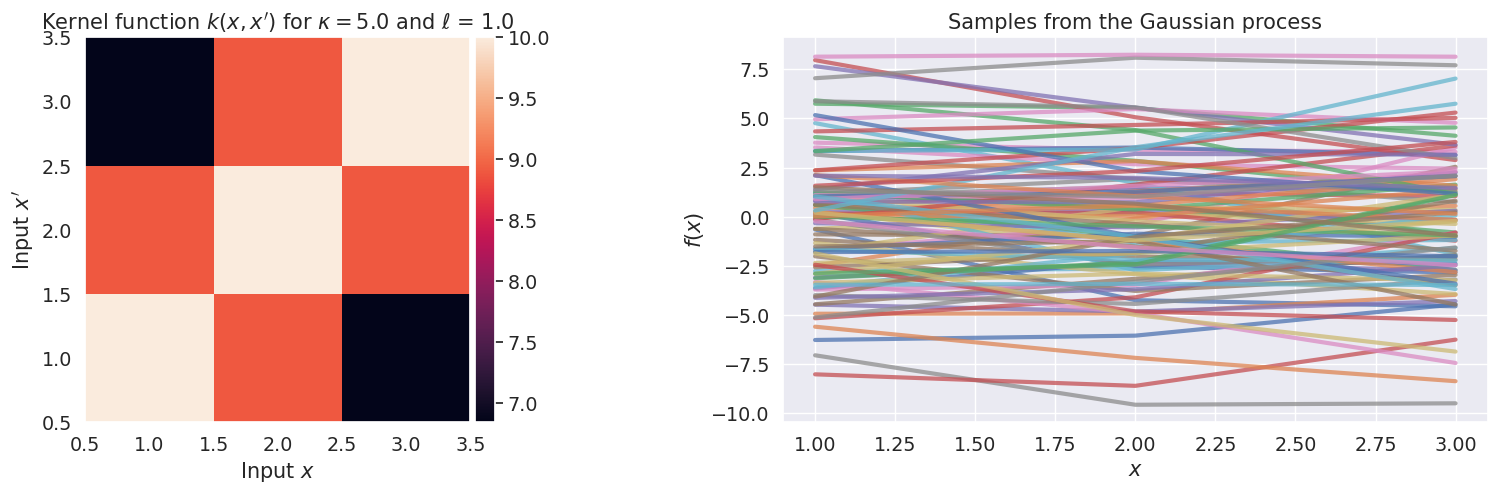

In [91]:
# Part 4

X = jnp.array([1, 2, 3])[:, None]
y = jnp.array([1, 1, 0])[:, None]

m = jnp.array([1.56, 0.84, -0.32])
S = jnp.array([2.69, 1.49, 0.42, 1.46, 1.78, 1.2, 0.42, 1.2, 2.13]).reshape((3,3))
print(S)

# Gaussian process time!
hyper = bayesian.Hyperparameters(5, 1, 1)
def kernel_fun1(tau, hyperparameters: bayesian.Hyperparameters):
    return hyperparameters.kappa*(1 + jnp.exp(-0.25*tau**2/hyperparameters.lengthscale**2))

gp = bayesian.StationaryIsotropicKernel(kernel_fun1)
K = gp.construct_kernel(X, X, hyper)
x_star = jnp.array([4])[:,None]
k = gp.construct_kernel(X, x_star, hyper)
k_small = gp.construct_kernel(x_star, x_star, hyper)

mu_fs = k.T @ jnp.linalg.solve(K, m)
sigma_fs = k_small - k.T @ jnp.linalg.solve(K, K - S) @ jnp.linalg.solve(K, k)

print(mu_fs)
print(sigma_fs)

# Plot later for verification.

# 4.4
# Apply the probit approximation to the previous result.
probit = scipy.stats.norm.cdf(mu_fs/jnp.sqrt(8/jnp.pi + sigma_fs))
print(probit) # The probability of y being equal to 1
# Bernoulli of this value.
key = random.key(0)
bayesian.plot_kernel(X, K, hyper, key, 100)

# 4.5
# The new kernel function scales the covariance matrix of the gaussian process by a constant facter 1/10. In our standard setup this is equivalent to using a smaller kappa value.
# This both reduces the variance and covariance of the sampled values causing them to regress more strongly towards the mean of the gaussian process.
# We do not see as extreme funnctions before the sigmoid transformation meaning the model is not as certain.



# Part 5
Solution to Q5.1 through Q5.5: See handwritten solution on appendix E

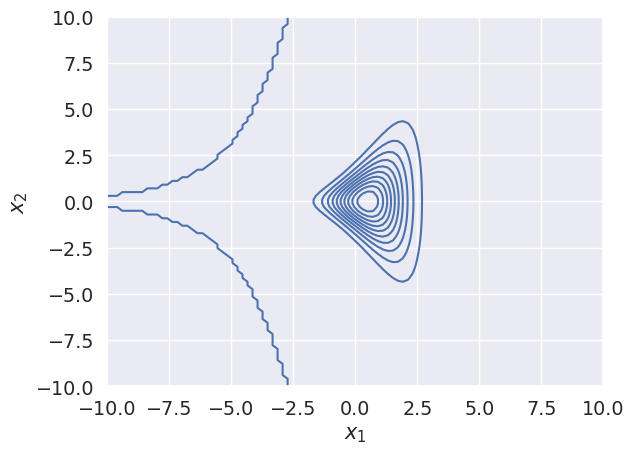

In [110]:
# Part 5

log_lik = lambda z, x : log_npdf(x, 0, jnp.exp(z)) + log_npdf(z, 1, 1)
fig, ax = plt.subplots(1,1)
xs = jnp.linspace(-10, 10, 100)
zs = jnp.linspace(-10, 10, 100)
bayesian.plot_contour(ax, log_lik, zs, xs, transform= lambda x : jnp.exp(x))


MCMC done: accept_rate=0.465  t=13.7s
MCMC done: accept_rate=0.467  t=13.1s


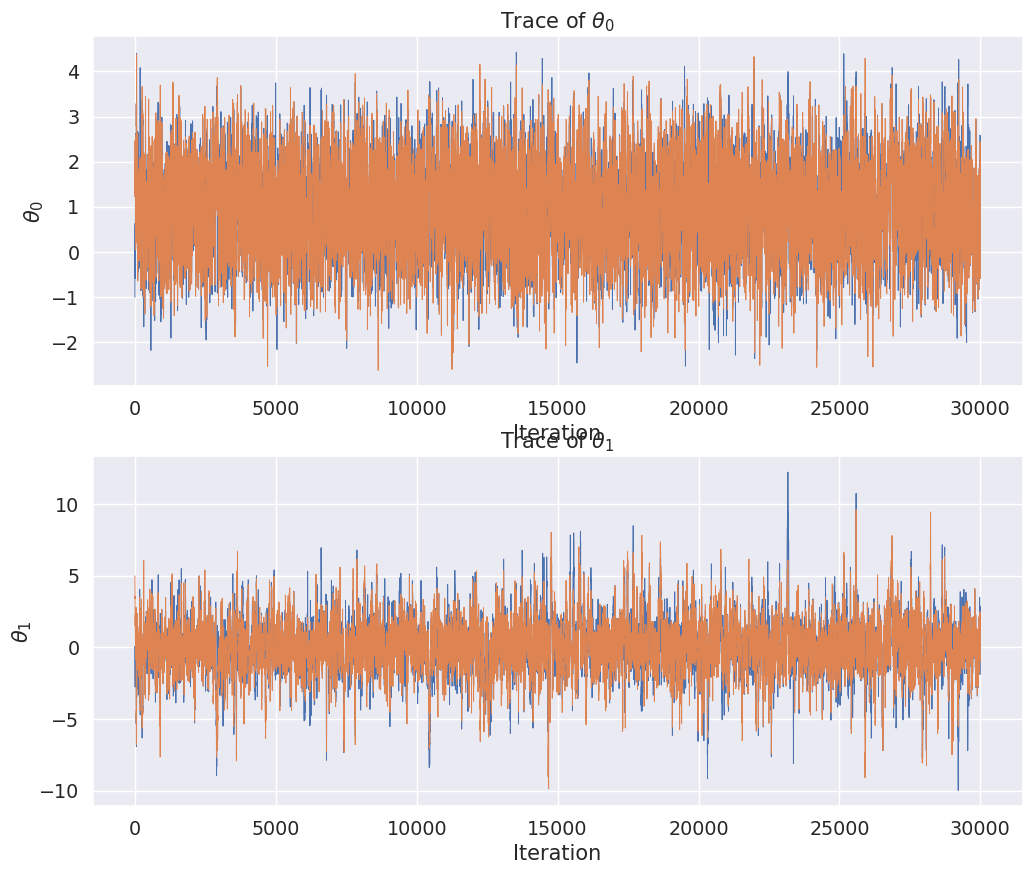

(<Figure size 1800x600 with 6 Axes>,
 array([[<Axes: title={'center': 'Full trace  $\\theta_0$'}, xlabel='Iteration', ylabel='$\\theta_0$'>,
         <Axes: title={'center': 'Post-warmup trace  $\\theta_0$  $\\hat{R}$=1.000'}, xlabel='Iteration', ylabel='$\\theta_0$'>,
         <Axes: title={'center': 'Histogram  $\\theta_0$  ESS=6021'}, xlabel='$\\theta_0$'>],
        [<Axes: title={'center': 'Full trace  $\\theta_1$'}, xlabel='Iteration', ylabel='$\\theta_1$'>,
         <Axes: title={'center': 'Post-warmup trace  $\\theta_1$  $\\hat{R}$=1.001'}, xlabel='Iteration', ylabel='$\\theta_1$'>,
         <Axes: title={'center': 'Histogram  $\\theta_1$  ESS=2319'}, xlabel='$\\theta_1$'>]],
       dtype=object))

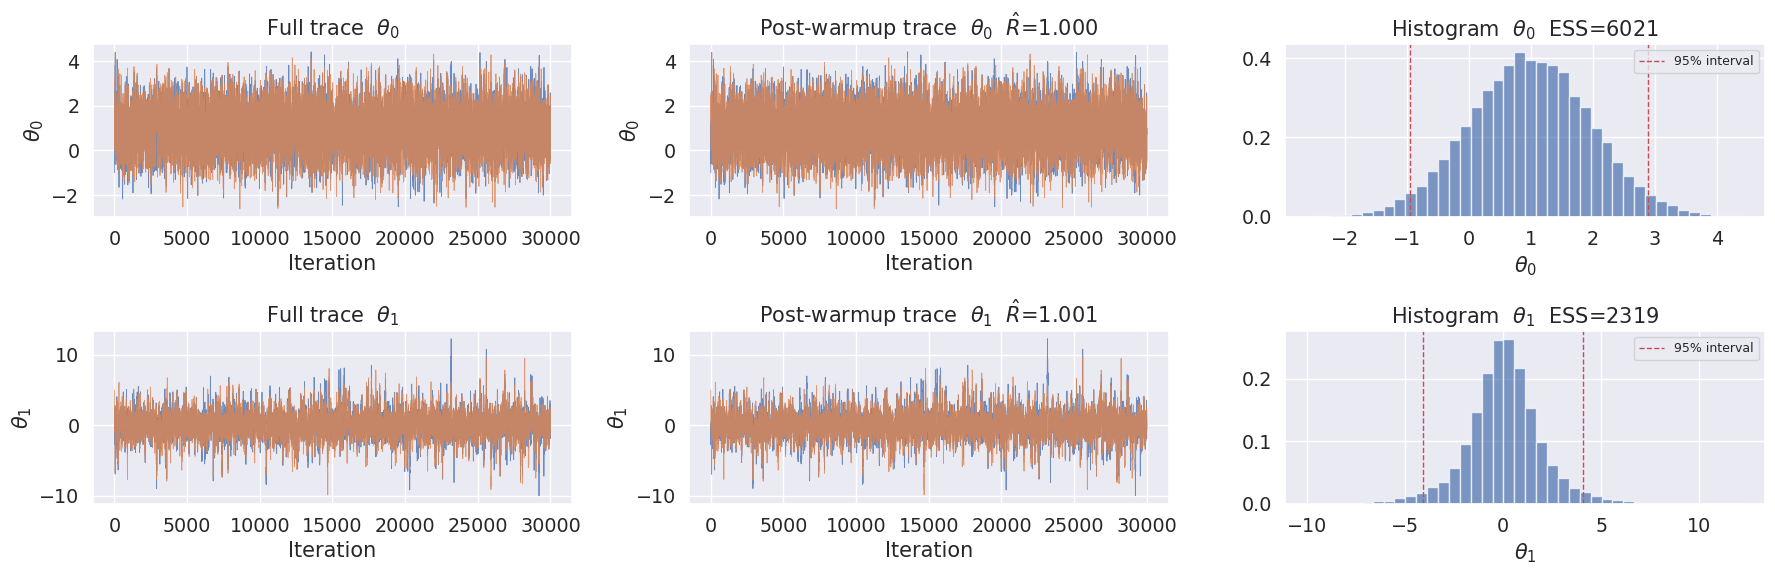

In [120]:
theta_1 = jnp.array([-1, 0])
theta_2 = jnp.array([2, 5])

from bayesian import metropolis, plot_trace, plot_mcmc_diagnostics
iter = 30000
thetas1 = metropolis(lambda theta : log_lik(theta[0], theta[1]), 2, jnp.sqrt(2), iter, theta_init=theta_1, seed = 1)
thetas2 = metropolis(lambda theta : log_lik(theta[0], theta[1]), 2, jnp.sqrt(2), iter, theta_init=theta_2, seed = 1)
fig, ax = plt.subplots(2, 1, figsize = (12, 10))
plot_trace(ax, thetas1)
plot_trace(ax, thetas2)
plt.show()
thetas_all = jnp.concat((thetas1[None,:], thetas2[None, :]), axis=0)
plot_mcmc_diagnostics(thetas_all)

In [121]:
# We compute the expection of this function empirically using the samples.

thetas_all.shape

fzx = (thetas_all[:, :, 0] - thetas_all[:, :, 1])**2
print(fzx.mean())

print((thetas_all[:, :, 1] < 1).mean())

samples = jnp.concatenate([thetas1, thetas2])
z, x = samples.T
print(f'Mean is {jnp.mean( (z - x)**2):3.2f}')

5.499631495738059
0.73487544
Mean is 5.50
